# Import libraries

In [69]:
# Data Exploration and Analysis
import pandas as pd
import numpy as np

# Stats and Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import PolynomialFeatures

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



# Load the dataset

In [70]:
df = pd.read_csv('../datasets/titanic.csv')

# Dataset overview

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [72]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Identify null values

In [73]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Numerical and categorical features

In [74]:
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Handeling missing values using SimpleInputer

In [75]:
# numerical imputation using median strategy
num_imputer = SimpleImputer(strategy='median')
df[numerical_features] = num_imputer.fit_transform(df[numerical_features])

In [76]:
# Categorical imputation using most frequent strategy
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_features] = cat_imputer.fit_transform(df[categorical_features])

# Verify missing valyes

In [77]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

# KNN imputation 

KNN a machine learning technique used to fill in missing data in a dataset. It replaces missing values (NaN) by finding the k most similar data points (neighbors) to the row with the missing value and averaging them.

In [78]:
# load the dataset again to check if the imputation worked
df_knn = pd.read_csv('../datasets/titanic.csv')

In [79]:
# Select numerical features for KNN imputation
numerical_features_knn = ['Age', 'SibSp', 'Parch', 'Fare']

In [80]:
# Apply knn imputation
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[numerical_features_knn] = knn_imputer.fit_transform(df_knn[numerical_features_knn])

In [81]:
# Check if the imputation worked
df_knn.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

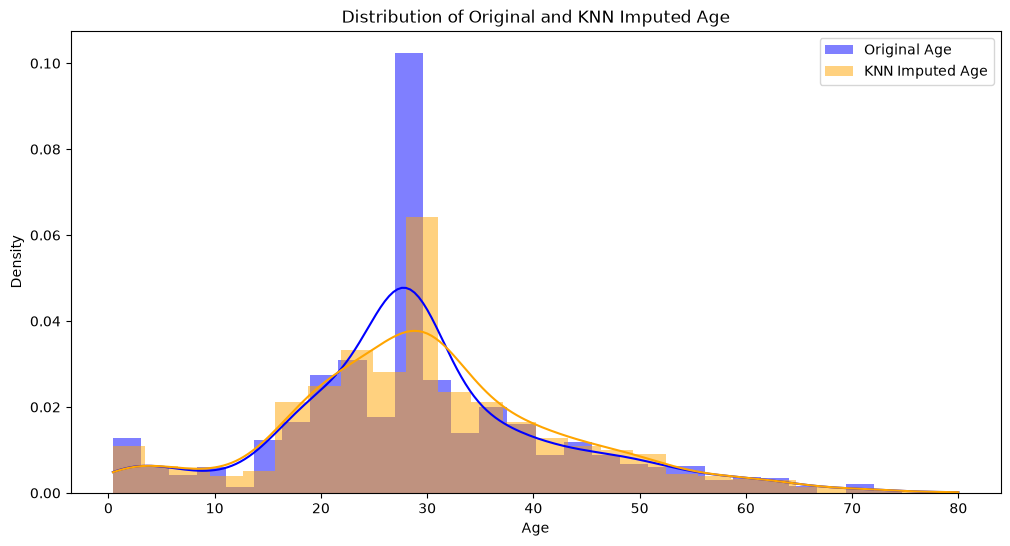

In [53]:
# Compare the distribution of the original and imputed data for 'Age' feature
plt.figure(figsize=(12, 6))
sns.histplot(df['Age'], color='blue', label='Original Age', kde=True, stat="density", linewidth=0)
sns.histplot(df_knn['Age'], color='orange', label='KNN Imputed Age', kde=True, stat="density", linewidth=0)
plt.title('Distribution of Original and KNN Imputed Age')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

# Label Encoding

Label Encoding is Suitable for binary categorical variables.

In [82]:
label_encoder = LabelEncoder()
df['sex_encoder'] =label_encoder.fit_transform(df['Sex'])
df[['Sex', 'sex_encoder']].head()

,Sex,sex_encoder
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


# One-Hot encoding

One-hot encoding is a data preprocessing technique used to convert categorical data into a numerical format. 

In [83]:
encoder = OneHotEncoder(sparse_output=False)
encoder = encoder.fit(df[['Embarked']])


In [85]:
encoded_df = pd.DataFrame(encoder.transform(df[['Embarked']]), columns=encoder.get_feature_names_out(['Embarked']))
encoded_df.head()

,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [87]:
# Merge the encoded DataFrame with the original DataFrame
concat_df = pd.concat([df, encoded_df], axis=1, ignore_index=False)
concat_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,sex_encoder,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,NaN,S,1,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,0,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,NaN,S,0,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,NaN,S,1,0.0,0.0,1.0


# Feature acaling

In [ ]:
# Numerial feature scaling using StandardScaler
numerical_features_to_scale = ['Age', 'SibSp', 'Parch', 'Fare']
standard_scaler = StandardScaler()
standard_scaled_df = pd.DataFrame(scaler.fit_transform(concat_df[numerical_features_to_scale]), columns=numerical_features_to_scale)    


,Age,SibSp,Parch,Fare
0,-0.565736,0.432793,-0.473674,-0.502445
1,0.663861,0.432793,-0.473674,0.786845
2,-0.258337,-0.474545,-0.473674,-0.488854
3,0.433312,0.432793,-0.473674,0.420730
4,0.433312,-0.474545,-0.473674,-0.486337


In [ ]:
# MinMaxScaler
minmax_scaler = MinMaxScaler()
df